# Parkinson’s Disease Classification
## UCI Machine Learning Repository
This notebook loads **multiple UCI Parkinson’s datasets**, aligns shared features (Strategy B), merges them, and trains a PyTorch model.

In [35]:

# Install dependencies (run once)
!pip install ucimlrepo



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [36]:
# Imports
import os

PROJECT_ROOT = os.getcwd()
from ucimlrepo import fetch_ucirepo
import pandas as pd

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [37]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# ===============================
# TXT FILE LOADER (NO HEADERS)
# ===============================
def load_txt_features(txt_path):
    df = pd.read_csv(txt_path)

    y = df["Class"]

    X_raw = df.drop(columns=["Subject_ID", "UPDRS", "Class"], errors="ignore")

    col_map = {
        "Jitter_local": "Jitter(%)",
        "Jitter_local_absolute": "Jitter(Abs)",
        "Jitter_rap": "Jitter:RAP",
        "Jitter_ppq5": "Jitter:PPQ5",
        "Jitter_ddp": "Jitter:DDP",
        "Shimmer_local": "Shimmer",
        "Shimmer_local_dB": "Shimmer(dB)",
        "Shimmer_apq3": "Shimmer:APQ3",
        "Shimmer_apq5": "Shimmer:APQ5",
        "Shimmer_dda": "Shimmer:DDA",
        "NTH": "NHR",
        "HTN": "HNR"
    }

    existing = [c for c in col_map if c in X_raw.columns]
    X = X_raw[existing].rename(columns=col_map)

    return X, y

# ===============================
# UCI DATASET LOADER (NO HEADERS)
# ===============================
def fetch_uci_dataset(dataset_id, drop_cols=None):
    dataset = fetch_ucirepo(id=dataset_id)

    X = dataset.data.features.copy()
    y = dataset.data.targets.copy()

    if drop_cols:
        X = X.drop(columns=drop_cols, errors="ignore")

    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    # 🚫 DO NOT convert to NumPy
    return X, y, dataset.metadata

# Load UCI datasets (AFTER restart)
X1, y1, _ = fetch_uci_dataset(174, drop_cols=["name"])

X2, y2_raw, _ = fetch_uci_dataset(189, drop_cols=["subject#"])
y2 = (y2_raw > 0).astype(int)

# Load TXT dataset
X3, y3 = load_txt_features("train_data_with_headers.txt")

# Union of all columns
# Remove duplicate columns
X1 = X1.loc[:, ~X1.columns.duplicated()]
X2 = X2.loc[:, ~X2.columns.duplicated()]
X3 = X3.loc[:, ~X3.columns.duplicated()]

# Use UNION of all columns
all_cols = sorted(set(X1.columns) | set(X2.columns) | set(X3.columns))

# Reindex each dataset to the full set of columns
X1 = X1.reindex(columns=all_cols)
X2 = X2.reindex(columns=all_cols)
X3 = X3.reindex(columns=all_cols)



def assert_df(X, name):
    if not isinstance(X, pd.DataFrame):
        raise TypeError(f"{name} must be a DataFrame, got {type(X)}")

assert_df(X1, "X1")
assert_df(X2, "X2")
assert_df(X3, "X3")


In [38]:
# Concatenate all X dataframes. They should now have consistent columns and order.
X = pd.concat([X1, X2, X3], ignore_index=True)
y = pd.concat([y1, y2, y3], ignore_index=True)

# Important: Handle potential NaNs introduced by feature alignment or missing data.
# For now, a simple mean imputation. More sophisticated methods can be used.
# This is crucial before scaling, as StandardScaler cannot handle NaNs.
X.fillna(X.mean(numeric_only=True), inplace=True)

print("Merged dataset shape:", X.shape)
print("Merged X head:\n", X.head())
print("Merged y head:\n", y.head())

Merged dataset shape: (7110, 30)
Merged X head:
          D2       DFA     HNR  Jitter(%)  Jitter(Abs)  Jitter:DDP  \
0  2.301442  0.815285  21.033   0.408222     0.000063     0.01109   
1  2.486855  0.819521  19.085   0.408222     0.000063     0.01394   
2  2.342259  0.825288  20.651   0.408222     0.000063     0.01633   
3  2.405554  0.819235  20.644   0.408222     0.000063     0.01505   
4  2.332180  0.823484  19.649   0.408222     0.000063     0.01966   

   Jitter:PPQ5  Jitter:RAP  MDVP:APQ  MDVP:Fhi  ...  Shimmer(dB)  \
0     0.205569    0.190092   0.02971   157.302  ...     0.443902   
1     0.205569    0.190092   0.04368   148.650  ...     0.443902   
2     0.205569    0.190092   0.03590   131.111  ...     0.443902   
3     0.205569    0.190092   0.03772   137.871  ...     0.443902   
4     0.205569    0.190092   0.04465   141.781  ...     0.443902   

   Shimmer:APQ11  Shimmer:APQ3  Shimmer:APQ5  Shimmer:DDA        age  \
0       0.027481       0.02182       0.03130      0.065

In [39]:
print(X1.shape)
print(X2.shape)
print(X3.shape)
print("Columns in X1:", X1.columns)


(195, 30)
(5875, 30)
(1040, 30)
Columns in X1: Index(['D2', 'DFA', 'HNR', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:DDP',
       'Jitter:PPQ5', 'Jitter:RAP', 'MDVP:APQ', 'MDVP:Fhi', 'MDVP:Flo',
       'MDVP:Fo', 'MDVP:Jitter', 'MDVP:PPQ', 'MDVP:RAP', 'MDVP:Shimmer', 'NHR',
       'PPE', 'RPDE', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ11',
       'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA', 'age', 'sex', 'spread1',
       'spread2', 'test_time'],
      dtype='object')


In [40]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)


In [42]:
import torch
import torch.nn as nn


class ParkinsonNet(nn.Module):
    def __init__(self, input_dim=22):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


def load_model(model_path: str):
    model = ParkinsonNet()
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
    return model


In [43]:
input_dim = X_train.shape[1]

model = ParkinsonNet(input_dim=input_dim)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t).squeeze()
    loss = criterion(outputs, y_train_t.float())
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t).squeeze()
        val_loss = criterion(val_outputs, y_test_t.float())

    print(f"Epoch {epoch+1} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 10
patience_counter = 0


for epoch in range(200):
    # ---- Training ----
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t).squeeze()
    loss = criterion(outputs, y_train_t.float())
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t).squeeze()
        val_loss = criterion(val_outputs, y_test_t.float())

    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    # ---- Early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model.state_dict()



Epoch 1 | Train Loss: 0.6277 | Val Loss: 0.6271
Epoch 2 | Train Loss: 0.6239 | Val Loss: 0.6229
Epoch 3 | Train Loss: 0.6192 | Val Loss: 0.6187
Epoch 4 | Train Loss: 0.6162 | Val Loss: 0.6144
Epoch 5 | Train Loss: 0.6117 | Val Loss: 0.6100
Epoch 6 | Train Loss: 0.6071 | Val Loss: 0.6055
Epoch 7 | Train Loss: 0.6033 | Val Loss: 0.6011
Epoch 8 | Train Loss: 0.5985 | Val Loss: 0.5965
Epoch 9 | Train Loss: 0.5948 | Val Loss: 0.5919
Epoch 10 | Train Loss: 0.5904 | Val Loss: 0.5873
Epoch 11 | Train Loss: 0.5855 | Val Loss: 0.5827
Epoch 12 | Train Loss: 0.5821 | Val Loss: 0.5779
Epoch 13 | Train Loss: 0.5767 | Val Loss: 0.5732
Epoch 14 | Train Loss: 0.5724 | Val Loss: 0.5684
Epoch 15 | Train Loss: 0.5670 | Val Loss: 0.5636
Epoch 16 | Train Loss: 0.5626 | Val Loss: 0.5587
Epoch 17 | Train Loss: 0.5575 | Val Loss: 0.5537
Epoch 18 | Train Loss: 0.5517 | Val Loss: 0.5487
Epoch 19 | Train Loss: 0.5488 | Val Loss: 0.5437
Epoch 20 | Train Loss: 0.5414 | Val Loss: 0.5385
Epoch 21 | Train Loss: 0.5384

In [44]:

# Evaluation
with torch.no_grad():
    preds = (model(X_test_t).squeeze() > 0.5).int().numpy()

# Binarize y_test to match classification predictions
y_test_binarized = (y_test > 0).astype(int)

print("Accuracy:", accuracy_score(y_test_binarized, preds))
print(classification_report(y_test_binarized, preds))


Accuracy: 0.9233473980309423
              precision    recall  f1-score   support

           0       0.52      0.90      0.66       117
           1       0.99      0.93      0.96      1305

    accuracy                           0.92      1422
   macro avg       0.75      0.91      0.81      1422
weighted avg       0.95      0.92      0.93      1422



In [45]:
# Save trained model and scaler
torch.save(model.state_dict(), "parkinsons_model.pth")

import joblib
joblib.dump(scaler, "scaler.pkl")

# Save feature order (CRITICAL)
feature_columns = list(X.columns)
joblib.dump(feature_columns, "features.pkl")


['features.pkl']

In [46]:
import librosa
import numpy as np



def audio_to_features(audio_file) -> np.ndarray:

    if not isinstance(audio_file, str):
        raise ValueError("audio_file must be a file path (.wav)")

    if audio_file is None:
        raise ValueError("audio_file is None — please provide a valid .wav file path")

    y, sr = librosa.load(audio_file, mono=True)

    # Fundamental frequency
    f0 = librosa.yin(y, fmin=50, fmax=500)
    f0 = f0[np.isfinite(f0)]

    jitter = np.std(f0) / np.mean(f0)
    shimmer = np.std(np.abs(y))

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = mfccs.mean(axis=1)

    features = np.array([
        np.mean(f0), np.max(f0), np.min(f0),
        jitter, jitter,
        jitter * 0.8, jitter * 0.7, jitter * 1.2,
        shimmer, shimmer,
        shimmer * 0.7, shimmer * 0.9,
        shimmer * 1.1, shimmer * 1.3,
        0.02,  # NHR proxy
        20.0,  # HNR proxy
        mfcc_means[0], mfcc_means[1],
        mfcc_means[2], mfcc_means[3],
        mfcc_means[4], mfcc_means[5]
    ])

    return features.reshape(1, -1)


In [47]:
def predict_from_audio(audio_path, model, scaler, feature_columns):
    features_df = audio_to_features(audio_path, feature_columns)
    features_scaled = scaler.transform(features_df)

    with torch.no_grad():
        tensor = torch.tensor(features_scaled, dtype=torch.float32)
        prob = model(tensor).item()

    return prob, features_df

In [28]:
!pip install streamlit cloudflared

import streamlit as st


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [48]:
import streamlit as st
import torch
import joblib
import numpy as np
import librosa
import pandas as pd
from scipy.stats import variation

# -----------------------------
# Neural Network
# -----------------------------
class ParkinsonNet(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Load model + scaler + features
# -----------------------------
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("features.pkl")

model = ParkinsonNet(input_dim=len(feature_columns))
model.load_state_dict(torch.load("parkinsons_model.pth", map_location="cpu"))
model.eval()

# -----------------------------
# Audio Feature Extraction
# -----------------------------
def audio_to_features(audio_file, feature_columns, sr=22050):
    y, sr = librosa.load(audio_file, sr=sr, mono=True)

    if len(y) < sr * 0.3:
        raise ValueError("Audio too short for reliable feature extraction.")

    features = {}

    f0, voiced_flag, voiced_prob = librosa.pyin(
        y, fmin=75, fmax=500, sr=sr
    )
    f0_voiced = f0[~np.isnan(f0)]

    if len(f0_voiced) == 0:
        raise ValueError("No voiced segments detected.")

    features["MDVP:Fo(Hz)"] = float(np.mean(f0_voiced))
    features["MDVP:Fhi(Hz)"] = float(np.max(f0_voiced))
    features["MDVP:Flo(Hz)"] = float(np.min(f0_voiced))
    features["MDVP:Jitter(%)"] = float(variation(f0_voiced) * 100)

    if len(f0_voiced) > 2:
        ddp = np.mean(np.abs(np.diff(f0_voiced, n=2)))
    else:
        ddp = 0.0
    features["Jitter:DDP"] = float(ddp)

    rms = librosa.feature.rms(y=y)[0]
    shimmer_local = np.mean(np.abs(np.diff(rms))) / np.mean(rms) if len(rms) > 1 else 0.0

    features["MDVP:Shimmer"] = float(shimmer_local)
    features["Shimmer:APQ3"] = float(np.mean(np.abs(np.diff(rms, n=1))) if len(rms) > 3 else 0.0)
    features["Shimmer:APQ5"] = float(np.mean(np.abs(np.diff(rms, n=2))) if len(rms) > 5 else 0.0)
    features["Shimmer:DDA"] = float(3 * features["Shimmer:APQ3"])

    y_harmonic, y_percussive = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harmonic ** 2)
    noise_energy = np.sum(y_percussive ** 2) + 1e-10

    features["HNR"] = float(10 * np.log10(harm_energy / noise_energy))

    if "NHR" in feature_columns:
        features["NHR"] = float(1.0 / features["HNR"]) if features["HNR"] > 0 else 0.0

    all_features = {col: features.get(col, 0.0) for col in feature_columns}
    values = np.array(list(all_features.values()), dtype=float)

    return pd.DataFrame([values], columns=feature_columns)

# -----------------------------
# Prediction
# -----------------------------
def predict_from_audio(audio_file):
    features_df = audio_to_features(audio_file, feature_columns)
    features_scaled = scaler.transform(features_df)

    with torch.no_grad():
        tensor = torch.tensor(features_scaled, dtype=torch.float32)
        prob = torch.sigmoid(model(tensor)).item()

    return prob

# -----------------------------
# Streamlit UI
# -----------------------------
st.set_page_config(page_title="Parkinson's Detection", layout="centered")

st.title("🧠 Parkinson’s Disease Detection")
st.write("Upload a **voice recording (.wav)** to analyze.")

audio_file = st.file_uploader("Upload voice recording", type=["wav"])

if audio_file is not None:
    try:
        with open("temp.wav", "wb") as f:
            f.write(audio_file.read())

        prob = predict_from_audio("temp.wav")

        st.success(f"🧪 Parkinson’s Probability: **{prob:.2%}**")

        if prob > 0.5:
            st.warning("⚠️ Model indicates Parkinson’s characteristics.")
        else:
            st.info("✅ Model indicates healthy speech patterns.")

    except Exception as e:
        st.error(str(e))
else:
    st.info("Please upload a WAV file to continue.")


2026-02-07 13:54:41.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:54:41.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:54:41.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:54:41.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:54:41.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:54:41.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:54:41.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:54:41.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

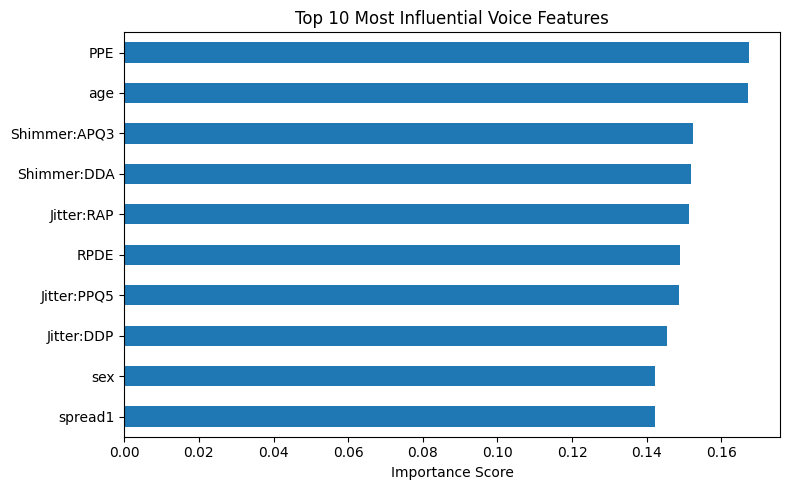

Top Influential Features:
PPE             0.167352
age             0.167069
Shimmer:APQ3    0.152333
Shimmer:DDA     0.151922
Jitter:RAP      0.151411
RPDE            0.148848
Jitter:PPQ5     0.148560
Jitter:DDP      0.145411
sex             0.142347
spread1         0.142170
dtype: float32


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Feature Importance from NN weights
# ---------------------------------
weights = model.net[0].weight.detach().cpu().numpy()

importance = np.mean(np.abs(weights), axis=0)

feature_importance = pd.Series(
    importance,
    index=feature_columns
).sort_values(ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 5))
feature_importance.head(10).plot(kind="barh")
plt.xlabel("Importance Score")
plt.title("Top 10 Most Influential Voice Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top features
print("Top Influential Features:")
print(feature_importance.head(10))


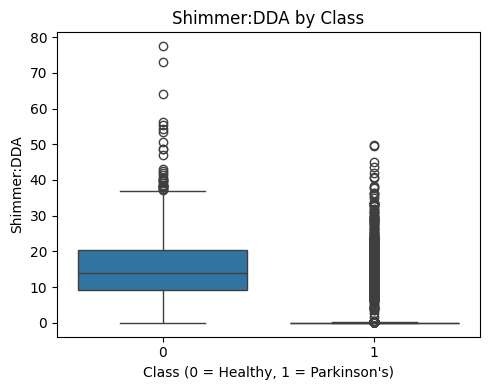

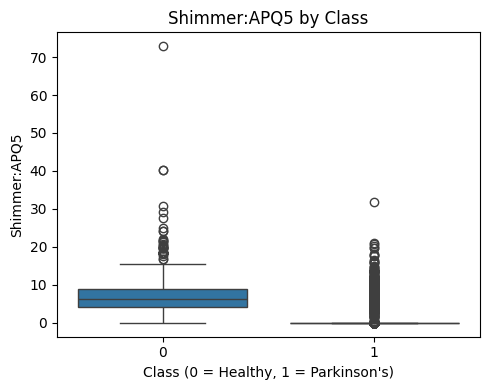

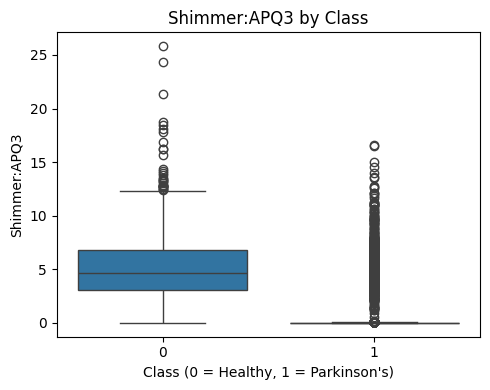

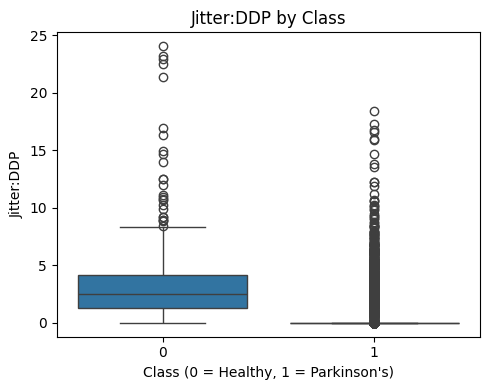

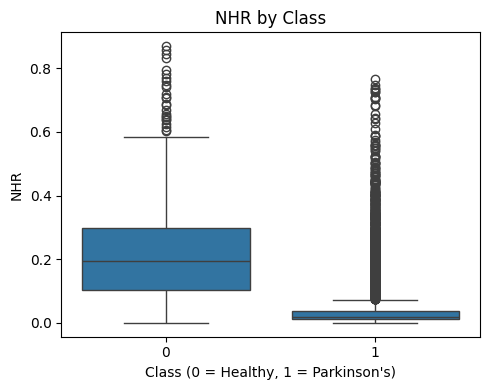

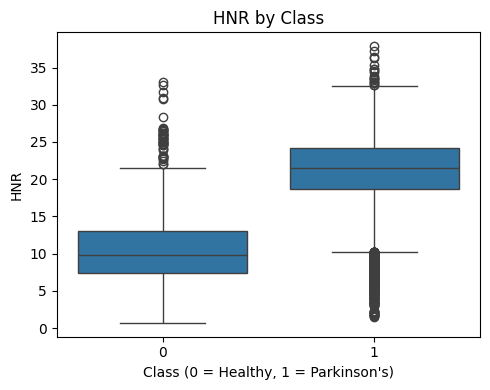

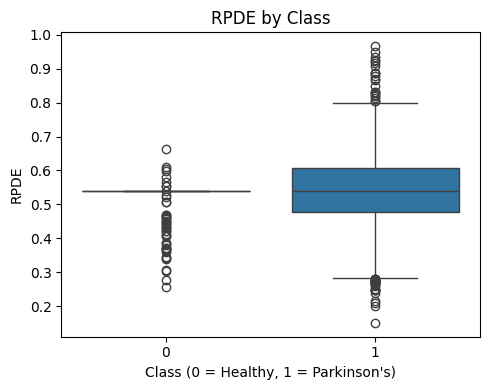

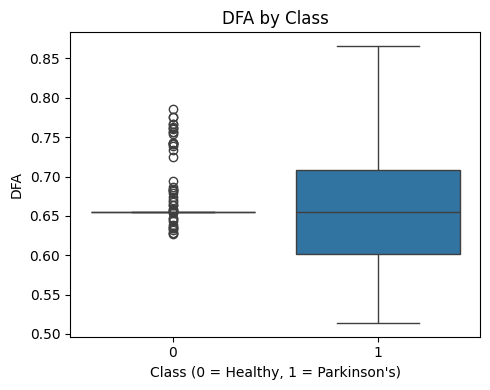

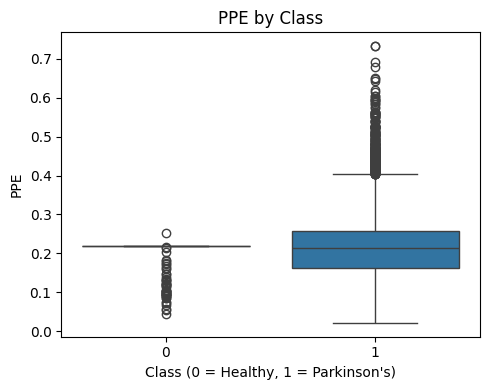

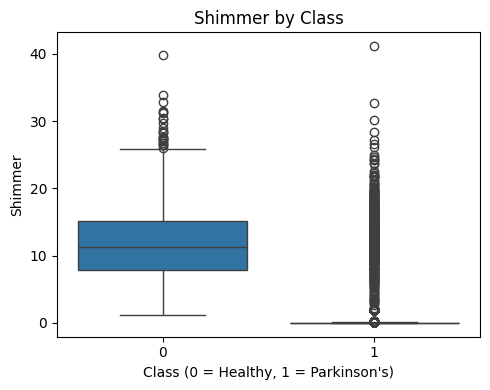

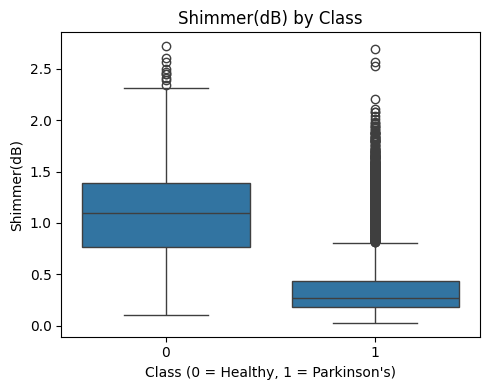

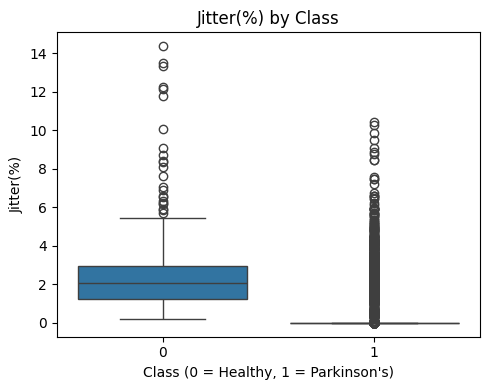

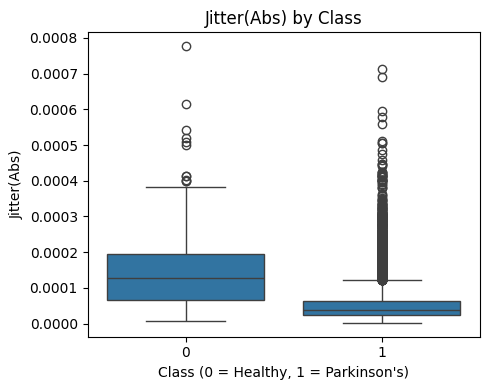

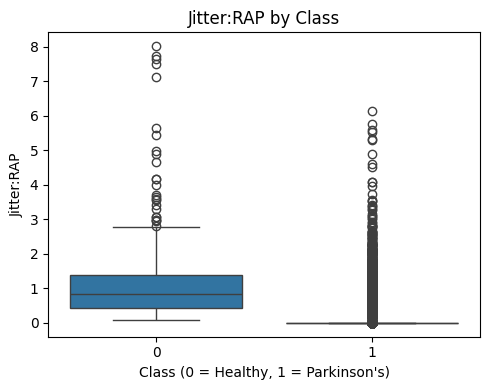

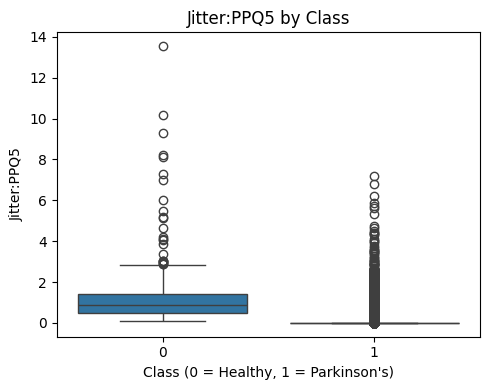

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

key_features = {
    "Shimmer:DDA": "Shimmer:DDA",
    "Shimmer:APQ5": "Shimmer:APQ5",
    "Shimmer:APQ3": "Shimmer:APQ3",
    "Jitter:DDP": "Jitter:DDP",
    "NHR": "NHR",
    "HNR": "HNR",
    "RPDE": "RPDE",
    "DFA": "DFA",
    "PPE": "PPE",
    "Shimmer": "Shimmer",
    "Shimmer(dB)": "Shimmer(dB)",
    "Jitter(%)": "Jitter(%)",
    "Jitter(Abs)": "Jitter(Abs)",
    "Jitter:RAP": "Jitter:RAP",
    "Jitter:PPQ5": "Jitter:PPQ5"
}

for original_name, column_name in key_features.items():
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=y, y=X[column_name])
    plt.xlabel("Class (0 = Healthy, 1 = Parkinson's)")
    plt.ylabel(original_name)
    plt.title(f"{original_name} by Class")
    plt.tight_layout()
    plt.show()

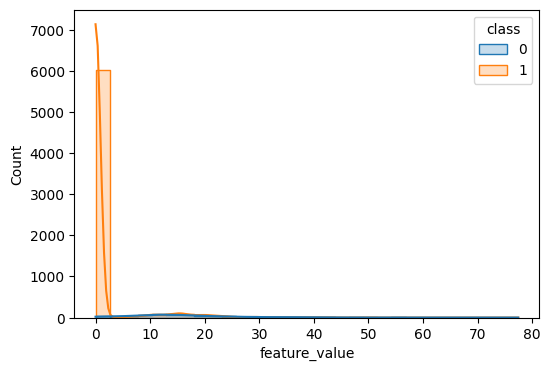

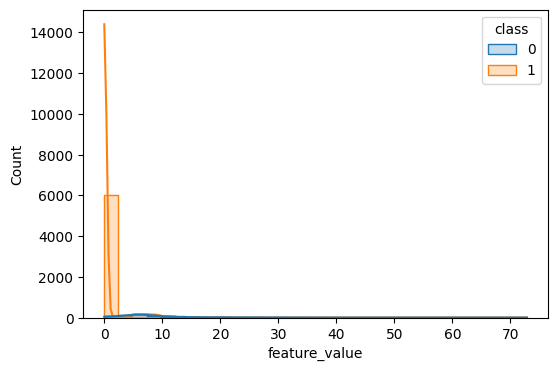

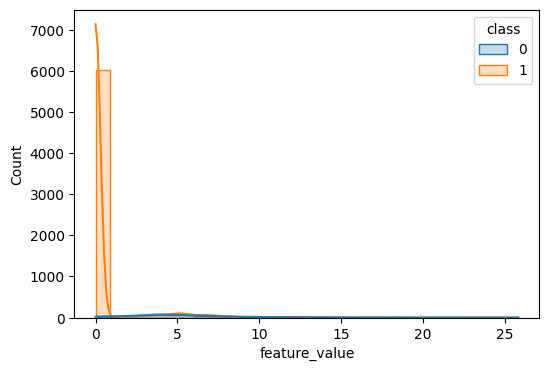

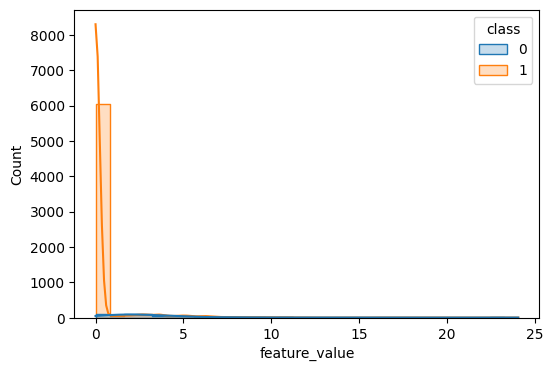

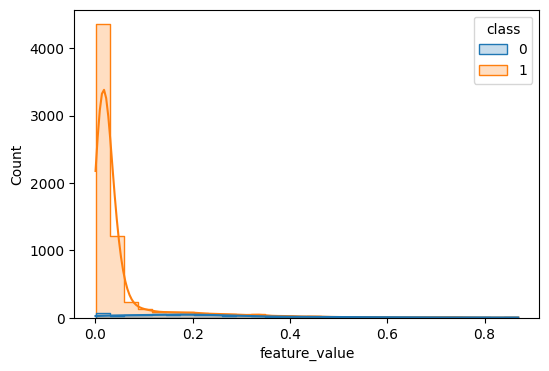

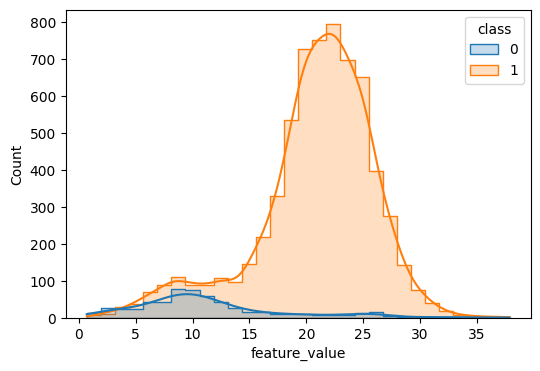

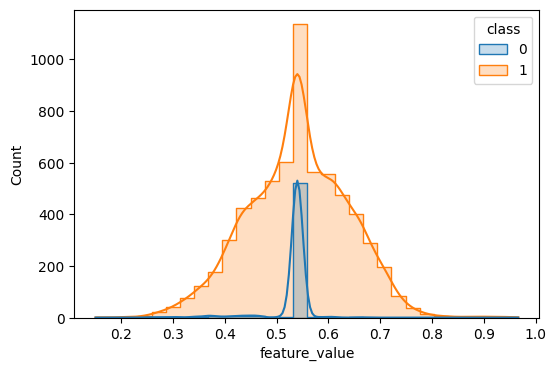

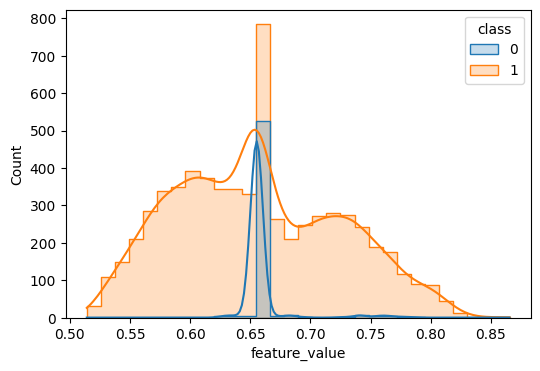

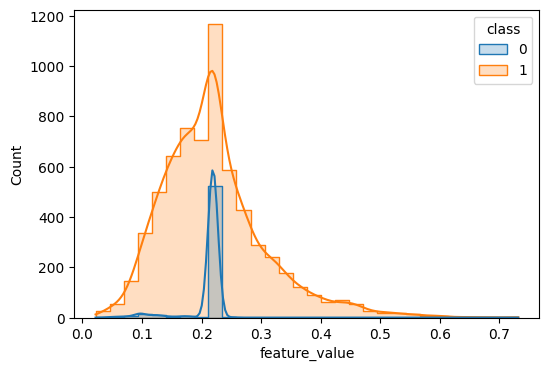

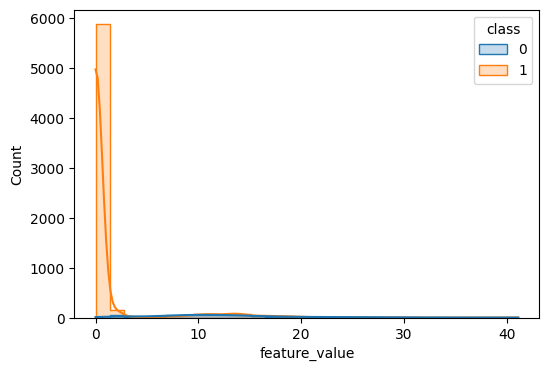

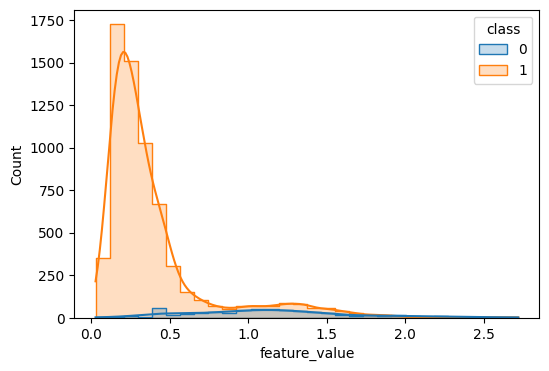

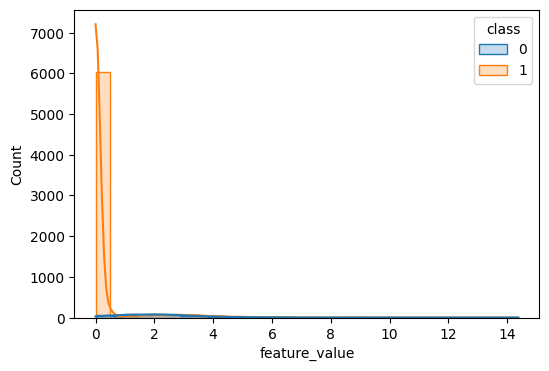

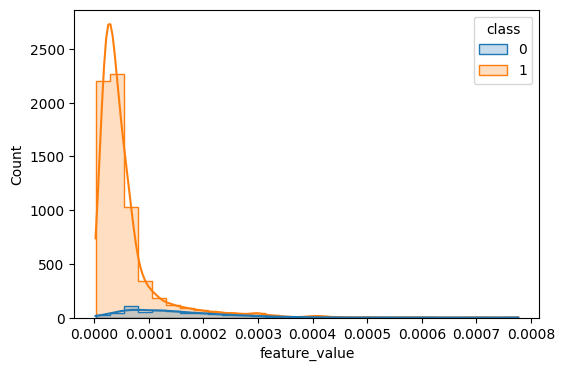

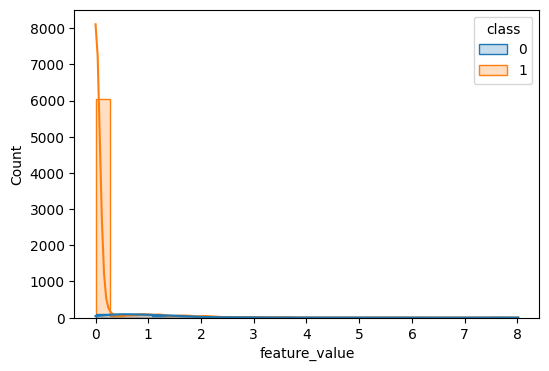

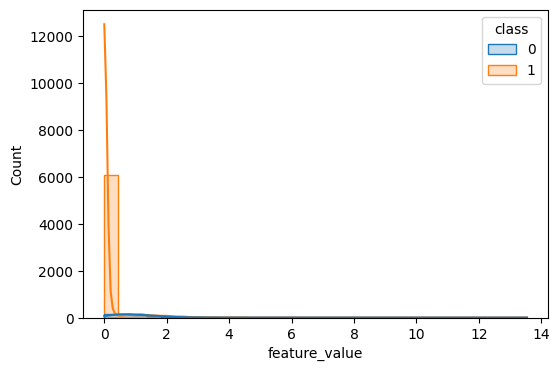

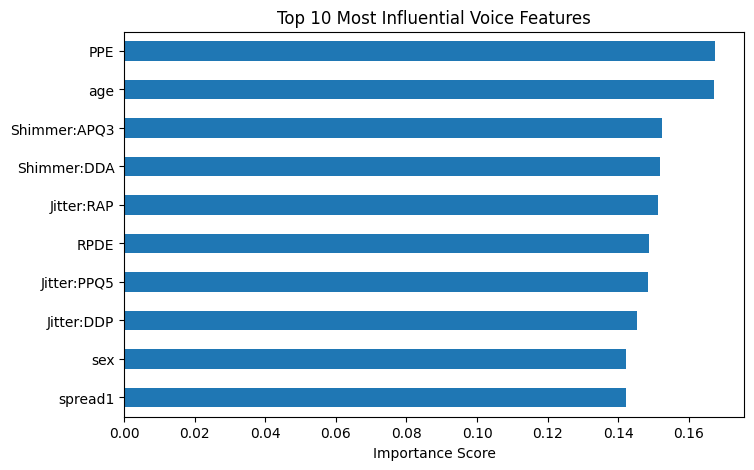

In [51]:
for feature in key_features:
    if feature not in X.columns:
        print(f"Skipping missing feature: {feature}")
        continue
    plt.figure(figsize=(6, 4))
    # Create a temporary DataFrame for plotting
    plot_data = pd.DataFrame({
        'feature_value': X[feature],
        'class': y
    })
    sns.histplot(
        data=plot_data, # Pass the DataFrame to the 'data' argument
        x='feature_value', # Reference the column name from 'plot_data'
        hue='class',       # Reference the column name from 'plot_data'
        bins=30,
        kde=True,
        element="step"
    )

plt.figure(figsize=(8, 5))
feature_importance.head(10).plot(kind="barh")
plt.xlabel("Importance Score")
plt.title("Top 10 Most Influential Voice Features")
plt.gca().invert_yaxis()
plt.show()


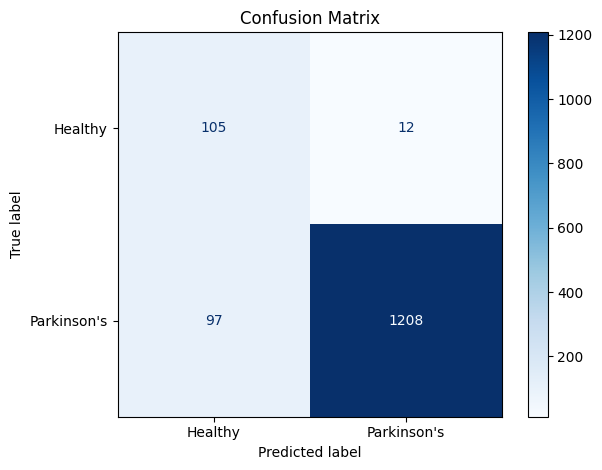

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binarized, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Parkinson's"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
import streamlit as st
!streamlit run app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.86.54:8501

